In [1]:
# Import libraries
import pandas as pd
import numpy as np

In [2]:
# --
df_meteo = pd.read_csv('output/meteo_merged_2326V4.csv')
df_meteo['yy-mm-dd'] = pd.to_datetime(df_meteo['yy-mm-dd'])
df_rd = pd.read_csv('output/rd_ttss_2326V4.csv')
df_rd['yy-mm-dd'] = pd.to_datetime(df_rd['yy-mm-dd'])
df_chla = pd.read_csv('output/chla_ttss_2326V4.csv')
df_chla['yy-mm-dd'] = pd.to_datetime(df_chla['yy-mm-dd'])

<Axes: xlabel='yy-mm-dd'>

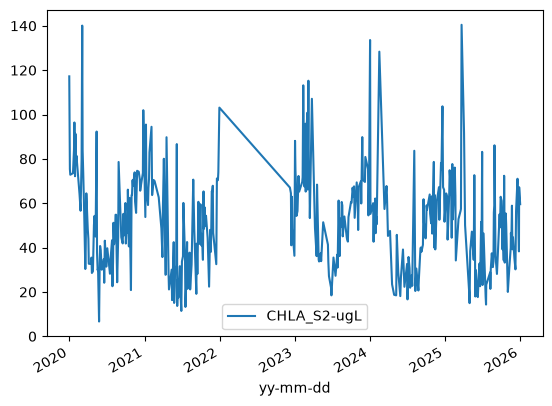

In [3]:
df_chla.plot('yy-mm-dd')

In [22]:
# --
df_merged = df_meteo.copy()

# --
df_merged['RD_ERA5-Jm2'] = df_rd['RD_ERA5-Jm2']

# --
df_merged = df_merged.merge(df_chla, on='yy-mm-dd', how="left")
df_merged['yy-mm-dd'] = pd.to_datetime(df_merged['yy-mm-dd'])

# --
#df_merged = df_merged.reset_index(inplace=True) 

In [23]:
df_merged

,yy-mm-dd,TP-ERA5_K,TP-EDAMCP_K,PP-ERA5_mm,WM-ERA5_ms,WD-EDAMCP_ms,RD_ERA5-Jm2,CHLA_S2-ugL
0,2020-01-01,295.67264,298.00,0.046566,2.063640,1.388890,2408588.0,NaN
1,2020-01-02,293.12730,295.25,0.016376,1.730708,0.555556,2777348.0,NaN
2,2020-01-03,294.13663,297.50,0.001578,1.696078,0.833334,3964360.0,75.399937
3,2020-01-04,295.40845,298.50,0.000870,1.747064,1.388890,3879344.0,NaN
4,2020-01-05,297.78854,300.95,1.537986,2.566181,1.666668,3796940.0,72.855106
...,...,...,...,...,...,...,...,...
2188,2025-12-28,296.43616,297.75,0.387467,1.837206,0.555556,2951564.0,NaN
2189,2025-12-29,296.70383,299.25,0.050873,1.394088,0.416667,3884652.0,NaN
2190,2025-12-30,298.47604,300.00,0.707946,1.476170,0.555556,3420692.0,NaN
2191,2025-12-31,298.54993,301.25,2.868198,1.298572,0.555556,3694948.0,NaN


In [24]:
def calculate_tsi(x):
    return 9.81*np.log(x)+30.6

def classify_value(x):
    if np.isnan(x):
        return np.nan
    elif x < 20:
        return 1
    elif x < 40:
        return 2
    elif x < 50:
        return 3
    elif x < 70:
        return 4
    else:
        return 5

df_merged['TSI'] = df_merged['CHLA_S2-ugL'].apply(calculate_tsi)
df_merged['CTSI'] = df_merged['TSI'].apply(classify_value)

In [25]:
df_merged.head()

,yy-mm-dd,TP-ERA5_K,TP-EDAMCP_K,PP-ERA5_mm,WM-ERA5_ms,WD-EDAMCP_ms,RD_ERA5-Jm2,CHLA_S2-ugL,TSI,CTSI
0,2020-01-01,295.67264,298.00,0.046566,2.063640,1.388890,2408588.0,NaN,NaN,NaN
1,2020-01-02,293.12730,295.25,0.016376,1.730708,0.555556,2777348.0,NaN,NaN,NaN
2,2020-01-03,294.13663,297.50,0.001578,1.696078,0.833334,3964360.0,75.399937,73.006731,5.0
3,2020-01-04,295.40845,298.50,0.000870,1.747064,1.388890,3879344.0,NaN,NaN,NaN
4,2020-01-05,297.78854,300.95,1.537986,2.566181,1.666668,3796940.0,72.855106,72.669916,5.0


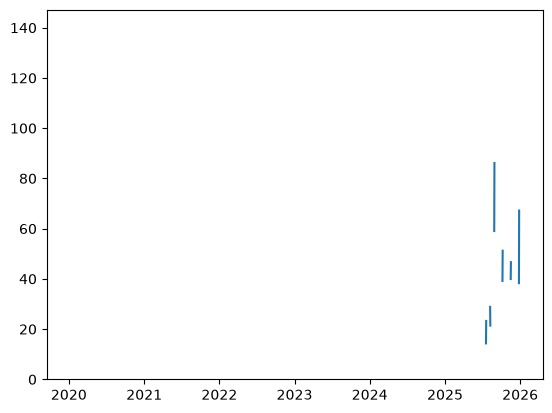

In [35]:
fig, ax = plt.subplots()
ax.plot(df_merged['yy-mm-dd'], df_merged['CHLA_S2-ugL'])
plt.show()

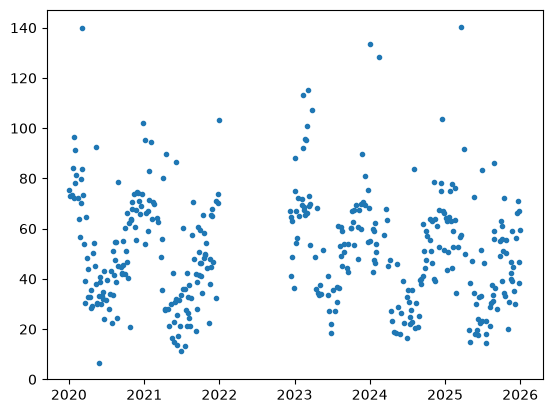

In [34]:
fig, ax = plt.subplots()
ax.plot(df_merged['yy-mm-dd'], df_merged['CHLA_S2-ugL'], marker='o', linestyle='none', markersize=3)
plt.show()

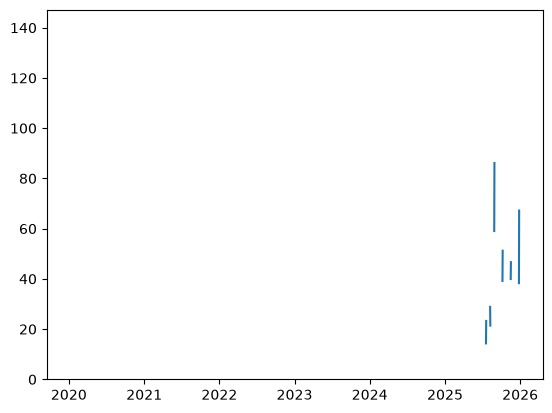

In [28]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(np.array(df_merged['yy-mm-dd']), np.array(df_merged['CHLA_S2-ugL']))

In [27]:
# --
df_merged_situ = df_merged.copy().drop(columns=['TP-ERA5_K', 'WM-ERA5_ms'])
df_merged_era5 = df_merged.copy().drop(columns=['TP-EDAMCP_K', 'WD-EDAMCP_ms'])

In [28]:
df_merged_situ

,yy-mm-dd,TP-EDAMCP_K,PP-ERA5_mm,WD-EDAMCP_ms,RD_ERA5-Jm2,CHLA_S2-ugL,TSI,CTSI
0,2020-01-01,298.00,0.046566,1.388890,2408588.0,NaN,NaN,NaN
1,2020-01-02,295.25,0.016376,0.555556,2777348.0,NaN,NaN,NaN
2,2020-01-03,297.50,0.001578,0.833334,3964360.0,75.399937,73.006731,5.0
3,2020-01-04,298.50,0.000870,1.388890,3879344.0,NaN,NaN,NaN
4,2020-01-05,300.95,1.537986,1.666668,3796940.0,72.855106,72.669916,5.0
...,...,...,...,...,...,...,...,...
2188,2025-12-28,297.75,0.387467,0.555556,2951564.0,NaN,NaN,NaN
2189,2025-12-29,299.25,0.050873,0.416667,3884652.0,NaN,NaN,NaN
2190,2025-12-30,300.00,0.707946,0.555556,3420692.0,NaN,NaN,NaN
2191,2025-12-31,301.25,2.868198,0.555556,3694948.0,NaN,NaN,NaN


In [29]:
# --
last_date_s2 = df_chla['yy-mm-dd'].values[-1]
lds2_7days = last_date_s2 - np.timedelta64(7, 'D')


In [30]:
# --
list_remove = ['PP-ERA5_mm', 'RD_ERA5-Jm2']

# --
for p in list_remove:
    
    values = df_merged_situ[p][df_merged_situ['yy-mm-dd'] <= lds2_7days].tolist()
    values.extend([np.nan] * 7)
    
    df_merged_situ[p] = values

In [31]:
# --
df_merged_situ.tail(10)

,yy-mm-dd,TP-EDAMCP_K,PP-ERA5_mm,WD-EDAMCP_ms,RD_ERA5-Jm2,CHLA_S2-ugL,TSI,CTSI
2183,2025-12-23,299.25,2.679050,0.694445,3612032.0,NaN,NaN,NaN
2184,2025-12-24,298.75,2.852082,0.833334,3878180.0,46.624771,68.291315,4.0
2185,2025-12-25,297.25,0.000428,0.694445,3816752.0,NaN,NaN,NaN
2186,2025-12-26,296.25,NaN,0.555556,NaN,38.296788,66.361041,4.0
2187,2025-12-27,298.25,NaN,0.972223,NaN,67.221361,71.880392,5.0
2188,2025-12-28,297.75,NaN,0.555556,NaN,NaN,NaN,NaN
2189,2025-12-29,299.25,NaN,0.416667,NaN,NaN,NaN,NaN
2190,2025-12-30,300.00,NaN,0.555556,NaN,NaN,NaN,NaN
2191,2025-12-31,301.25,NaN,0.555556,NaN,NaN,NaN,NaN
2192,2026-01-01,301.00,NaN,0.694445,NaN,59.580208,70.696643,5.0


In [34]:
# --
df_merged_era5.to_csv('output/merged_data_era5V4.csv', index=False)
df_merged_situ.to_csv('output/merged_data_situV4.csv', index=False)